<a href="https://colab.research.google.com/github/lee2998purdue/q15WkH4dkPUakgoM/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# data import

In [2]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/gdrive')

data_path = '/content/gdrive/My Drive/Apziva/Project 1 - Happy customers/ACME-HappinessSurvey2020.csv'

Mounted at /content/gdrive


In [3]:

try:
  df = pd.read_csv(data_path)
  print(df.head())
except FileNotFoundError:
  print(f"Error: The file at '{data_path}' was not found. Please check the path.")
except Exception as e:
  print(f"An error occurred while reading the CSV file: {e}")

   Y  X1  X2  X3  X4  X5  X6
0  0   3   3   3   4   2   4
1  0   3   2   3   5   4   3
2  1   5   3   3   3   3   5
3  0   5   4   3   3   3   5
4  0   5   4   3   3   3   5


data size, data type

In [ ]:
df.shape

(126, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


check data cleanness

In [ ]:
null_counts = df.isnull().sum()
print(f"number of null values for each column:\n{null_counts}")

number of null values for each column:
Y     0
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
dtype: int64


In [ ]:
attribute_df = df.iloc[:, 1:]
zero_counts_attribute_df = (attribute_df == 0).sum()
over_five_counts_attribute_df = (attribute_df > 5).sum()
print(f"number of zero values for each of the attribute columns:\n{zero_counts_attribute_df}")
print(f"number of values greater than 5 for each of the attribute columns:\n{over_five_counts_attribute_df}")

number of zero values for each of the attribute columns:
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
dtype: int64
number of values greater than 5 for each of the attribute columns:
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
dtype: int64


# univariate analysis


descriptive statistics

plot

In [ ]:
from numpy import average
for col in df.columns:
  print(col)
  print(f"minimum value for column {col}: {min(df[col])}")
  print(f"maximum value for column {col}: {max(df[col])}")
  print(f"mean value for column {col}: {(df[col]).mean()}")
  print(f"median value for column {col}: {(df[col]).median()}")
  print("\n")

Y
minimum value for column Y: 0
maximum value for column Y: 1
mean value for column Y: 0.5476190476190477
median value for column Y: 1.0


X1
minimum value for column X1: 1
maximum value for column X1: 5
mean value for column X1: 4.333333333333333
median value for column X1: 5.0


X2
minimum value for column X2: 1
maximum value for column X2: 5
mean value for column X2: 2.5317460317460316
median value for column X2: 3.0


X3
minimum value for column X3: 1
maximum value for column X3: 5
mean value for column X3: 3.3095238095238093
median value for column X3: 3.0


X4
minimum value for column X4: 1
maximum value for column X4: 5
mean value for column X4: 3.746031746031746
median value for column X4: 4.0


X5
minimum value for column X5: 1
maximum value for column X5: 5
mean value for column X5: 3.6507936507936507
median value for column X5: 4.0


X6
minimum value for column X6: 1
maximum value for column X6: 5
mean value for column X6: 4.253968253968254
median value for column X6: 4.0




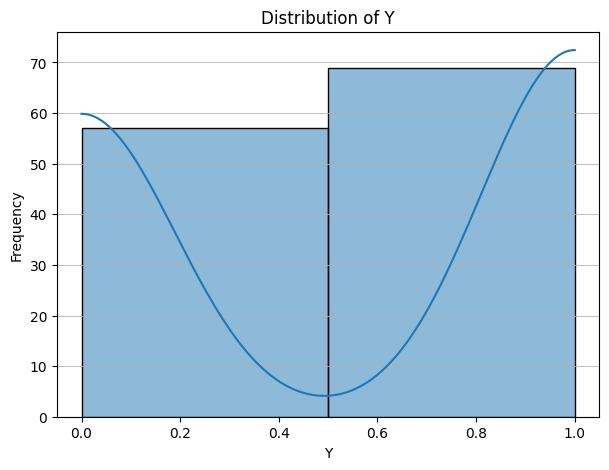

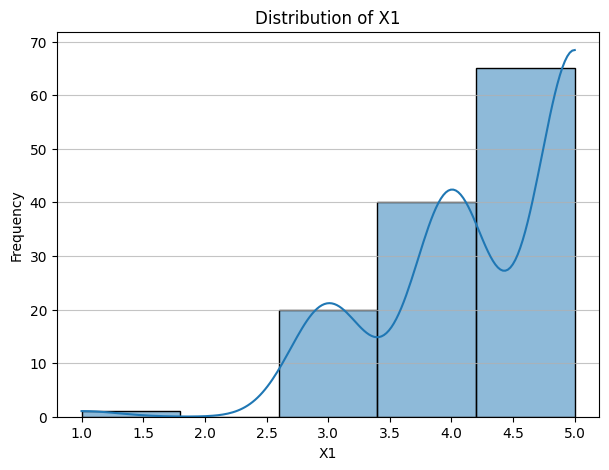

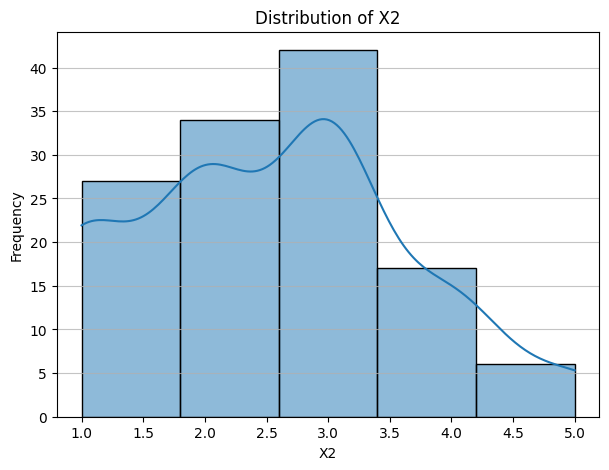

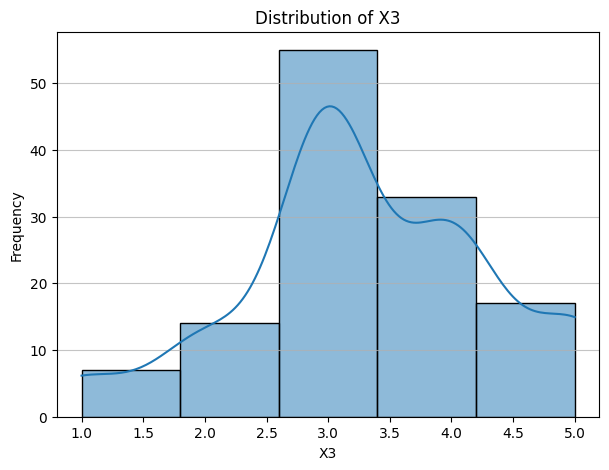

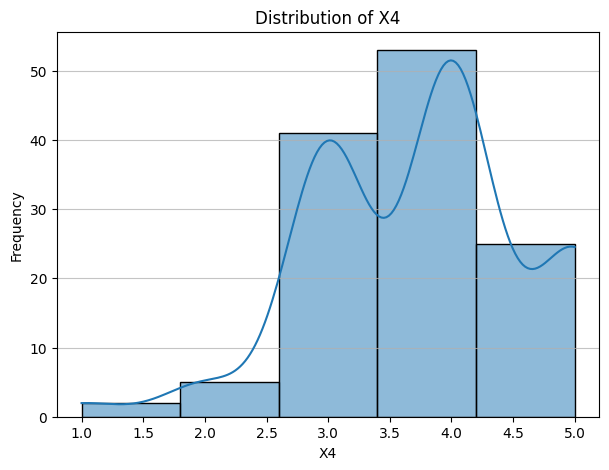

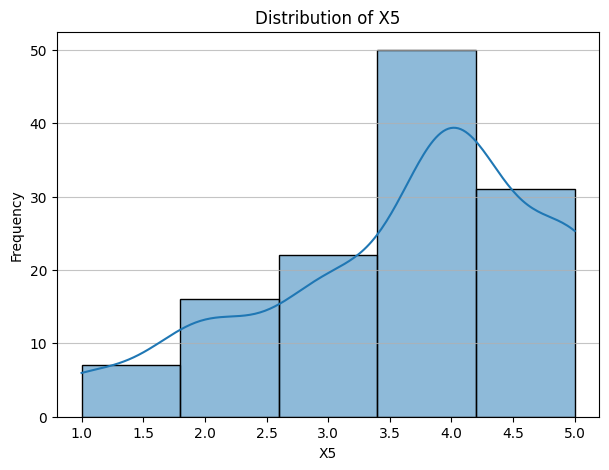

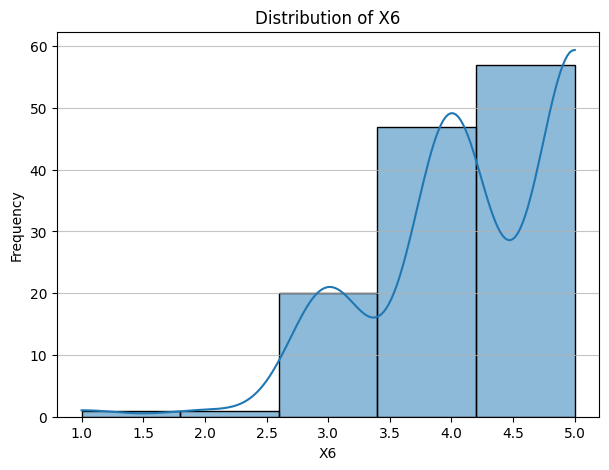

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(df['Y'], kde=True, bins=2)
plt.title('Distribution of Y')
plt.xlabel('Y')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

for col in attribute_df.columns:
    plt.figure(figsize=(7, 5))
    sns.histplot(attribute_df[col], kde=True, bins=5) # Assuming integer values from 1-5, bins=5 is appropriate
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

Almost half of the customers are unhappy...

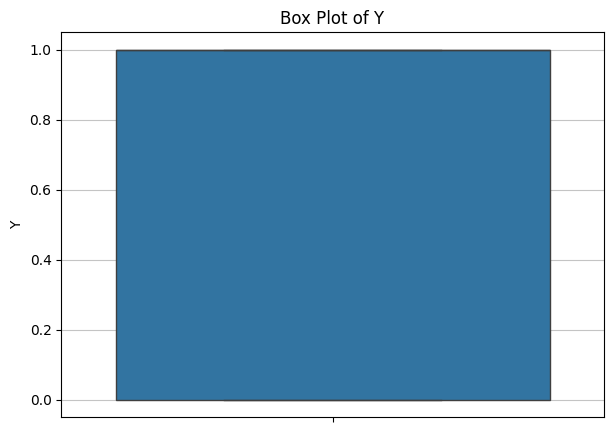

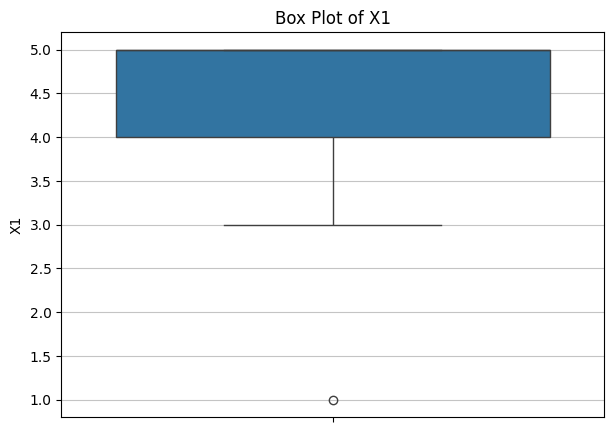

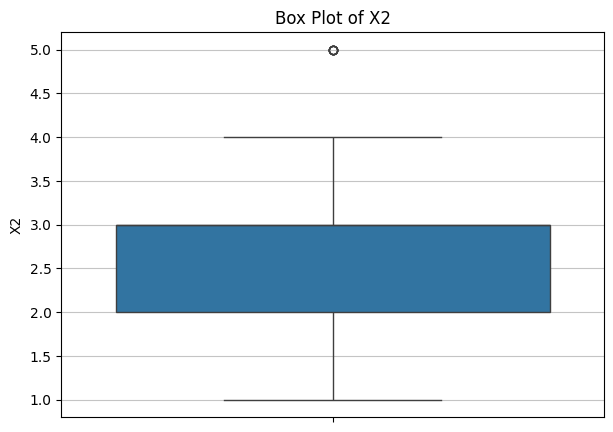

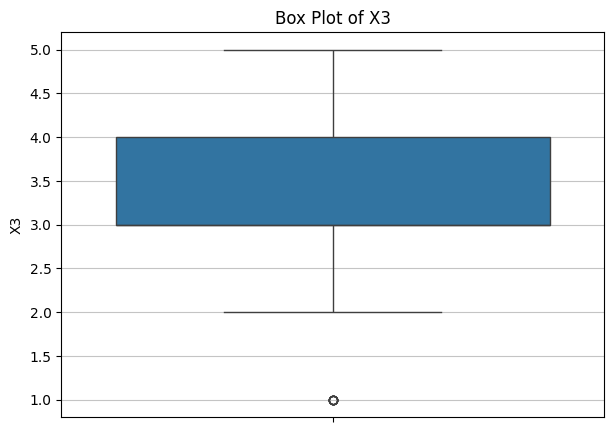

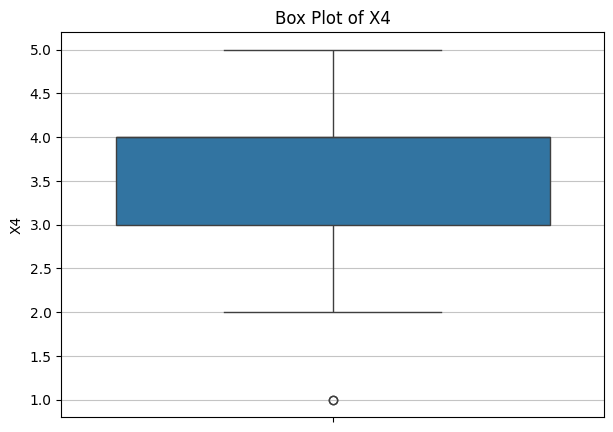

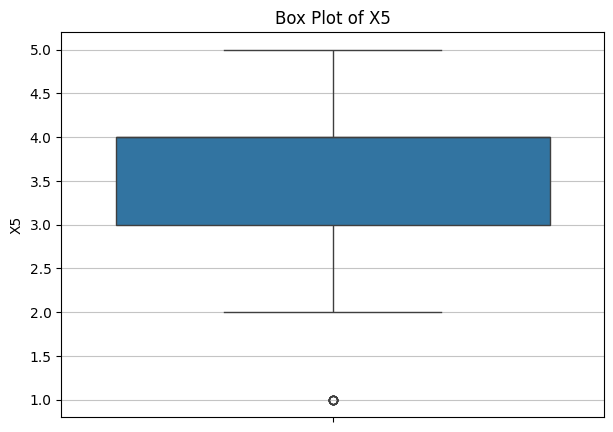

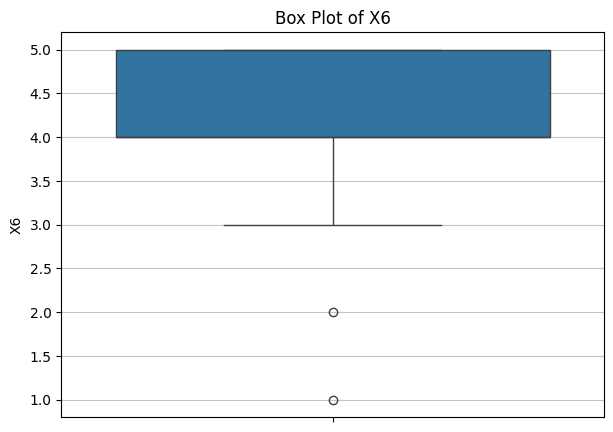

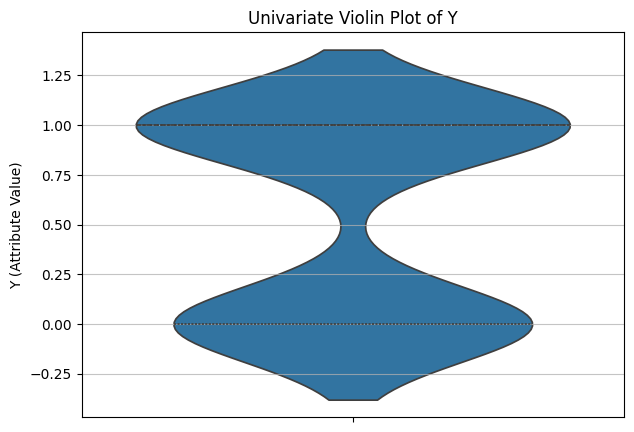

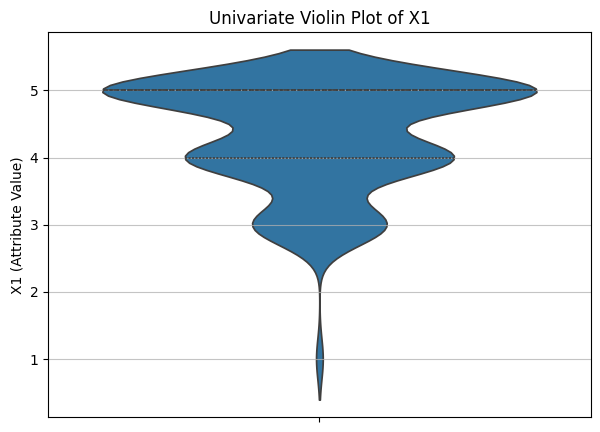

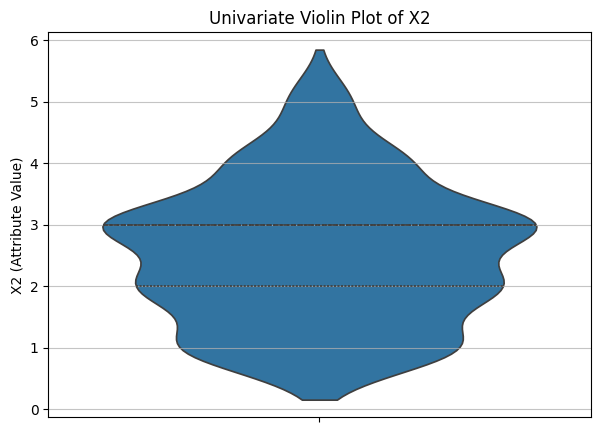

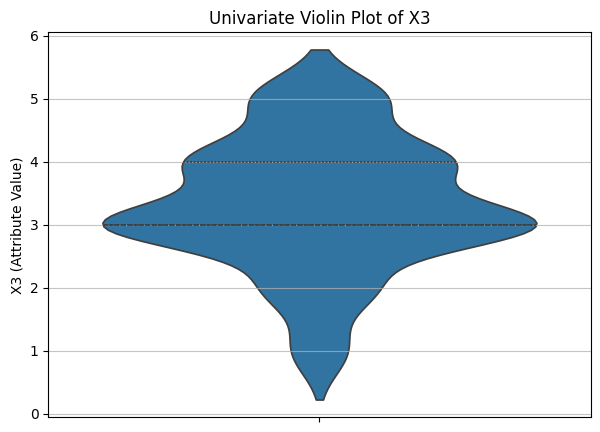

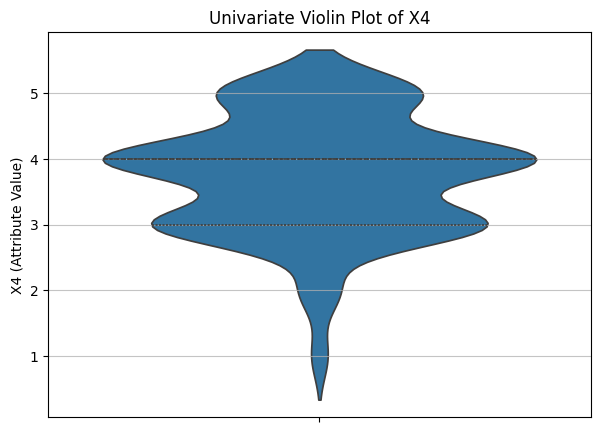

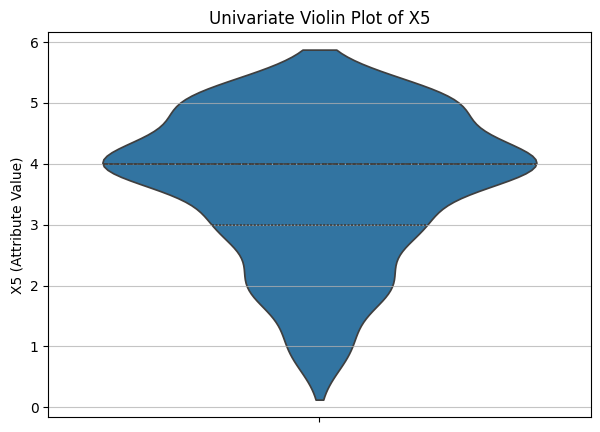

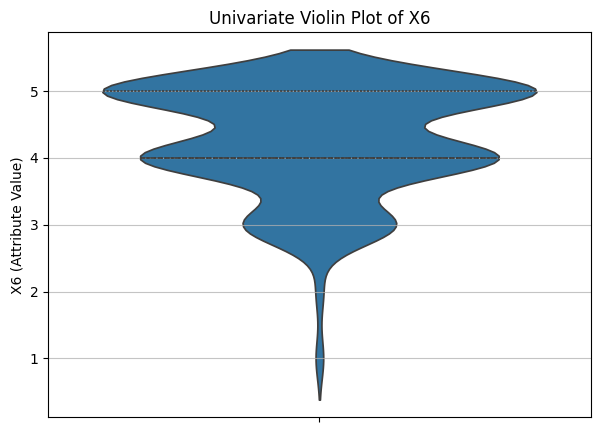

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns:
  plt.figure(figsize=(7, 5))
  sns.violinplot(y=df[col], inner='quartile')
  plt.title(f'Univariate Violin Plot of {col}')
  plt.ylabel(f'{col} (Attribute Value)')
  plt.grid(axis='y', alpha=0.75)
  plt.show()

# bivariate analysis

In [ ]:
df_y0 = df[df['Y'] == 0]
df_y1 = df[df['Y'] == 1]

print(f"Shape of df_y0: {df_y0.shape}")
print(f"Shape of df_y1: {df_y1.shape}")
print(f"First 5 rows of df_y0:\n{df_y0.head()}")
print(f"First 5 rows of df_y1:\n{df_y1.head()}")

Shape of df_y0: (57, 7)
Shape of df_y1: (69, 7)
First 5 rows of df_y0:
   Y  X1  X2  X3  X4  X5  X6
0  0   3   3   3   4   2   4
1  0   3   2   3   5   4   3
3  0   5   4   3   3   3   5
4  0   5   4   3   3   3   5
6  0   3   1   2   2   1   3
First 5 rows of df_y1:
    Y  X1  X2  X3  X4  X5  X6
2   1   5   3   3   3   3   5
5   1   5   5   3   5   5   5
7   1   5   4   4   4   4   5
12  1   5   2   4   5   5   5
15  1   3   2   4   3   4   4


In [ ]:
attribute_columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
mean_df_y0 = df_y0[attribute_columns].mean()
print(f"Mean of X attributes for Y=0:\n{mean_df_y0}")

Mean of X attributes for Y=0:
X1    4.087719
X2    2.561404
X3    3.140351
X4    3.684211
X5    3.368421
X6    4.105263
dtype: float64


In [ ]:
attribute_columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
mean_df_y1 = df_y1[attribute_columns].mean()
print(f"Mean of X attributes for Y=1:\n{mean_df_y1}")

Mean of X attributes for Y=1:
X1    4.536232
X2    2.507246
X3    3.449275
X4    3.797101
X5    3.884058
X6    4.376812
dtype: float64


In [ ]:
comparison_df = pd.DataFrame({'Mean_Y0': mean_df_y0, 'Mean_Y1': mean_df_y1})
comparison_df['Difference (Y1 - Y0)'] = comparison_df['Mean_Y1'] - comparison_df['Mean_Y0']

print("Comparison of Mean X attributes for Y=0 and Y=1:")
print(comparison_df)

print("\nSummary of Differences:")
for index, row in comparison_df.iterrows():
    if row['Difference (Y1 - Y0)'] > 0:
        print(f"  {index}: Mean for Y=1 is higher than Y=0 by {row['Difference (Y1 - Y0)']:.2f}")
    elif row['Difference (Y1 - Y0)'] < 0:
        print(f"  {index}: Mean for Y=1 is lower than Y=0 by {abs(row['Difference (Y1 - Y0)']):.2f}")
    else:
        print(f"  {index}: Mean for Y=1 is same as Y=0")

Comparison of Mean X attributes for Y=0 and Y=1:
     Mean_Y0   Mean_Y1  Difference (Y1 - Y0)
X1  4.087719  4.536232              0.448513
X2  2.561404  2.507246             -0.054157
X3  3.140351  3.449275              0.308924
X4  3.684211  3.797101              0.112891
X5  3.368421  3.884058              0.515637
X6  4.105263  4.376812              0.271548

Summary of Differences:
  X1: Mean for Y=1 is higher than Y=0 by 0.45
  X2: Mean for Y=1 is lower than Y=0 by 0.05
  X3: Mean for Y=1 is higher than Y=0 by 0.31
  X4: Mean for Y=1 is higher than Y=0 by 0.11
  X5: Mean for Y=1 is higher than Y=0 by 0.52
  X6: Mean for Y=1 is higher than Y=0 by 0.27


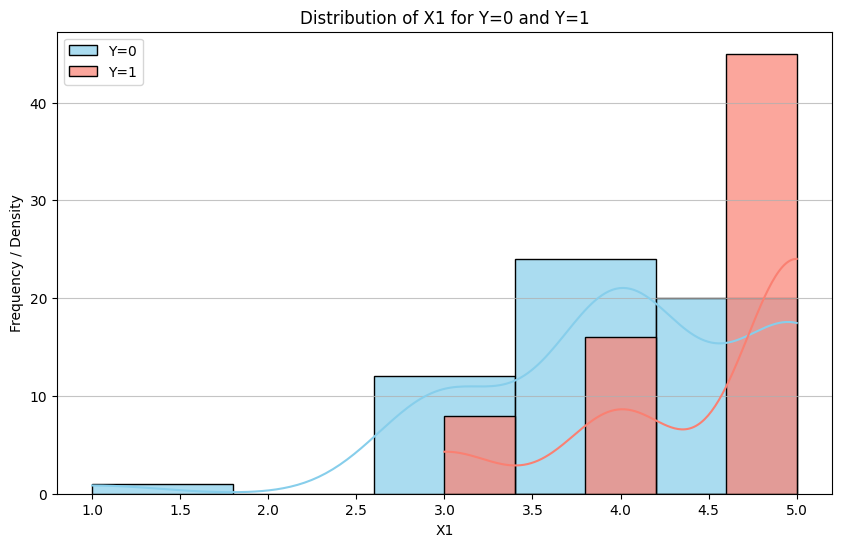

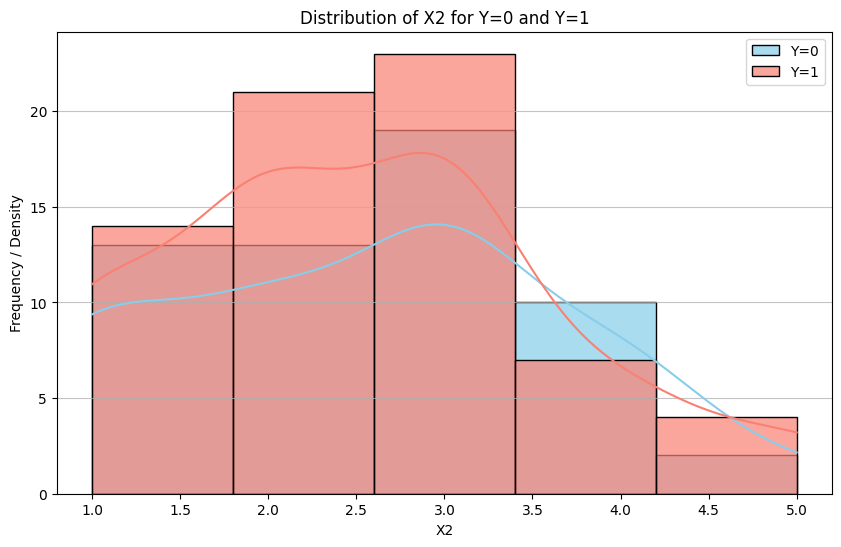

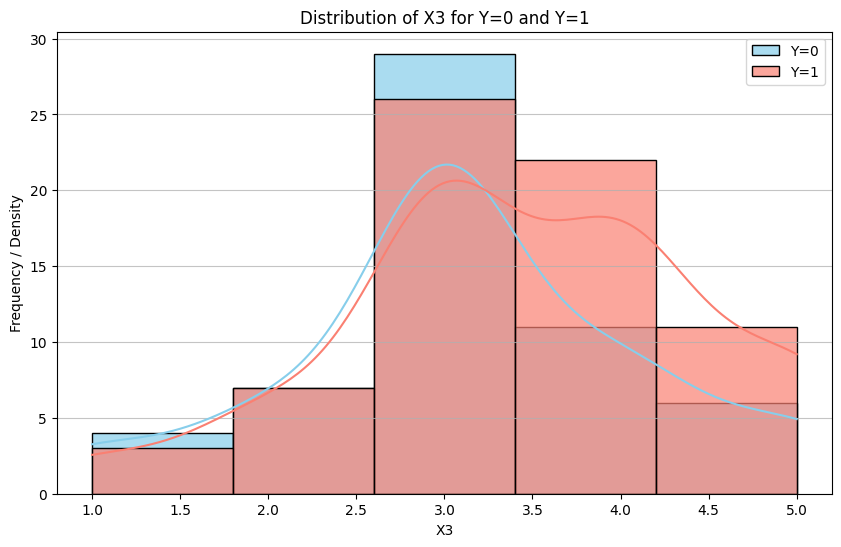

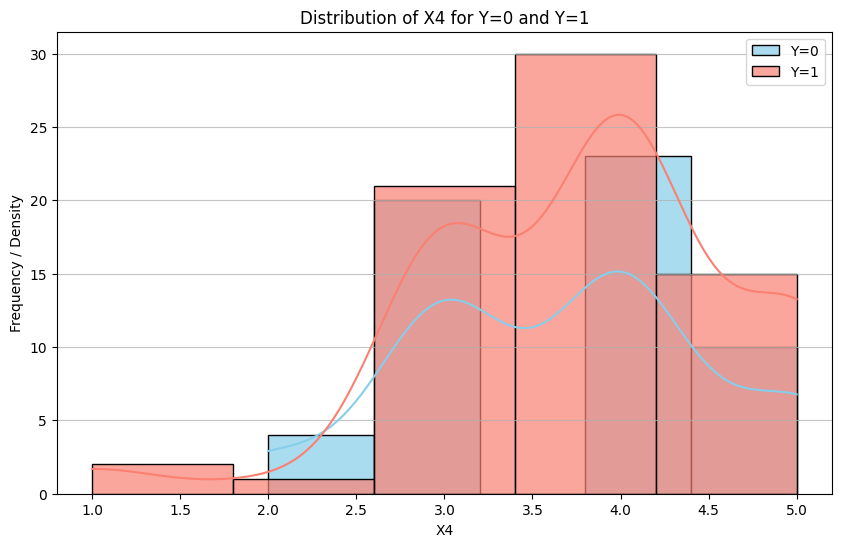

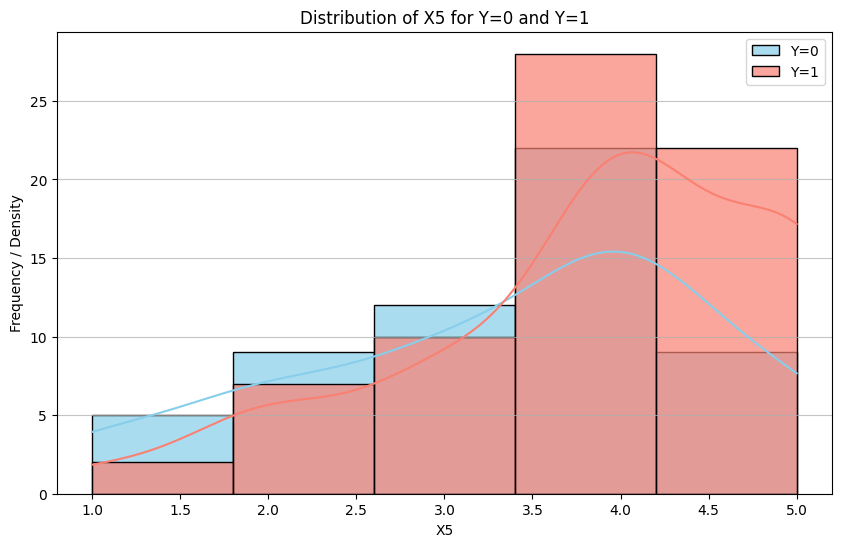

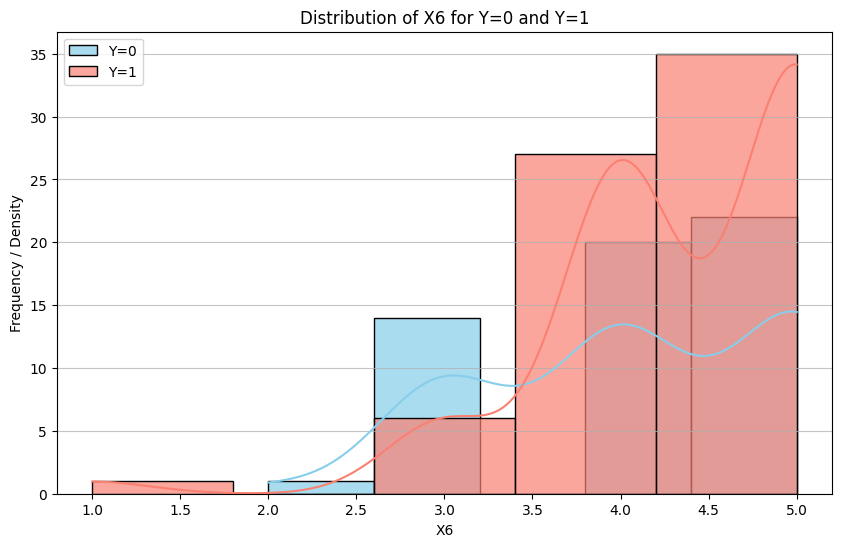

In [ ]:
for col in attribute_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_y0[col], kde=True, bins=5, color='skyblue', label='Y=0', alpha=0.7)
    sns.histplot(df_y1[col], kde=True, bins=5, color='salmon', label='Y=1', alpha=0.7)
    plt.title(f'Distribution of {col} for Y=0 and Y=1')
    plt.xlabel(col)
    plt.ylabel('Frequency / Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

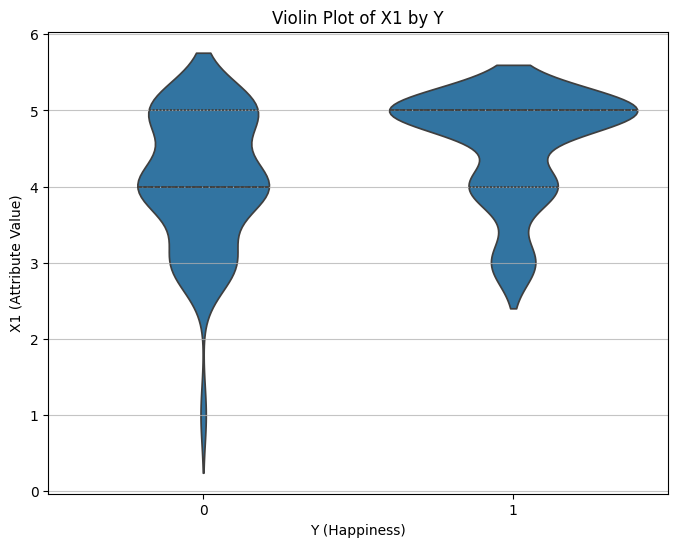

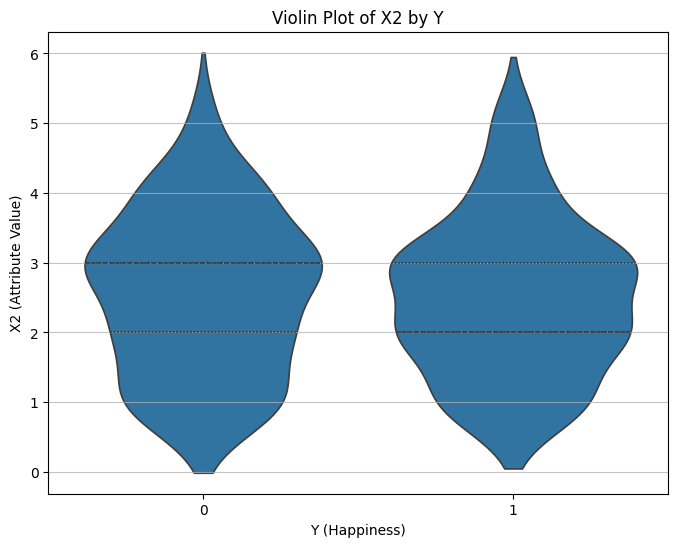

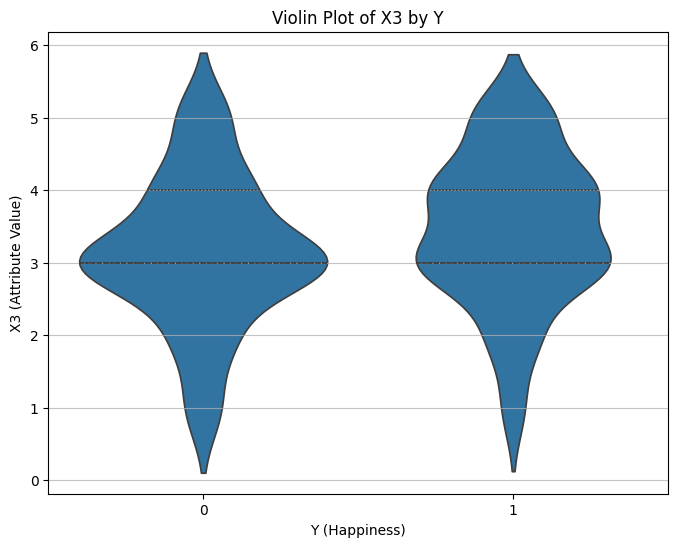

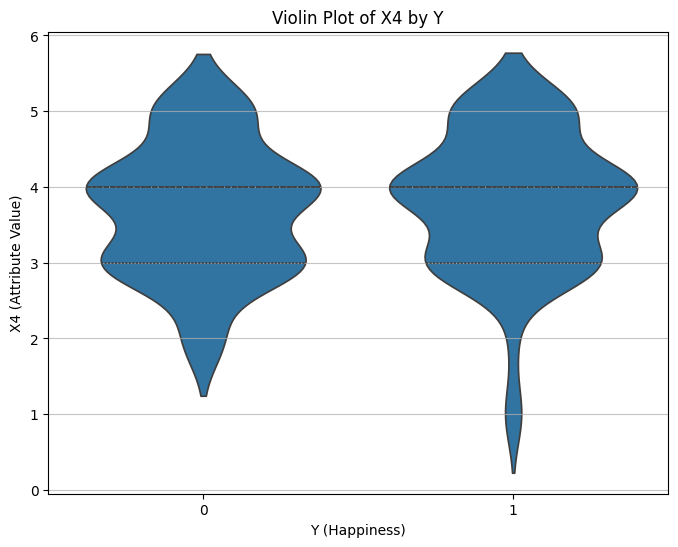

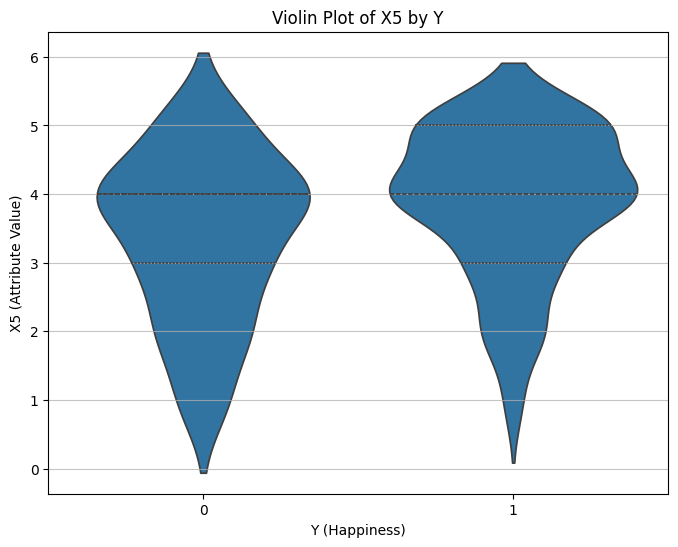

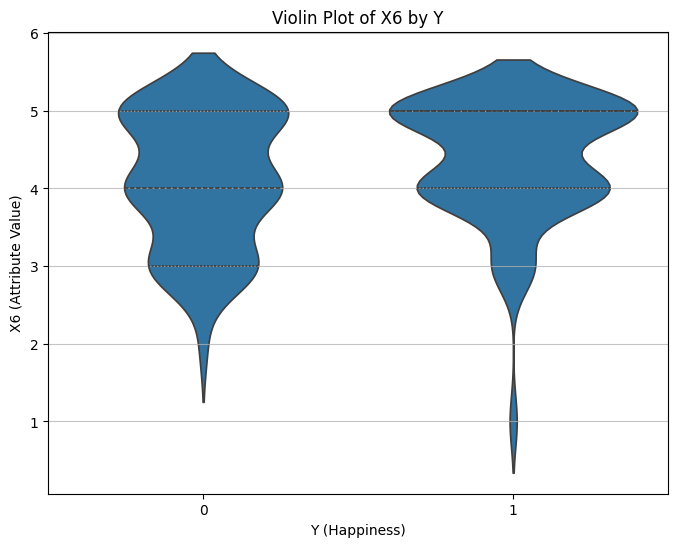

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in attribute_df.columns:
  plt.figure(figsize=(8, 6))
  sns.violinplot(x='Y', y=col, data=df, inner='quartile')
  plt.title(f'Violin Plot of {col} by Y')
  plt.xlabel('Y (Happiness)')
  plt.ylabel(f'{col} (Attribute Value)')
  plt.grid(axis='y', alpha=0.75)
  plt.show()

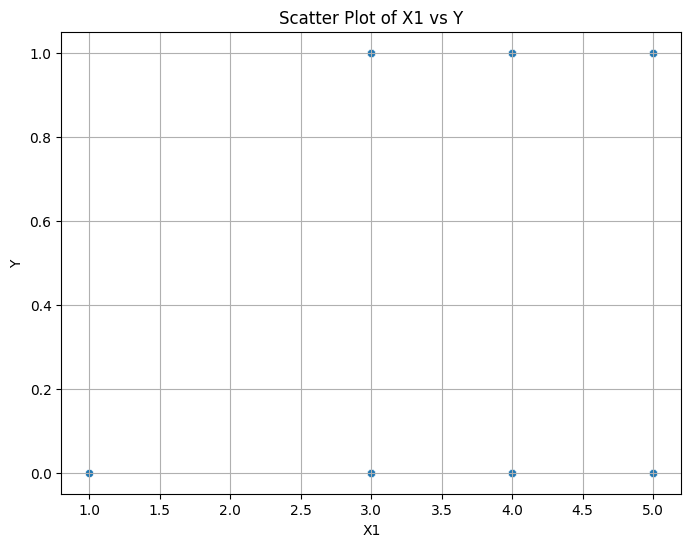

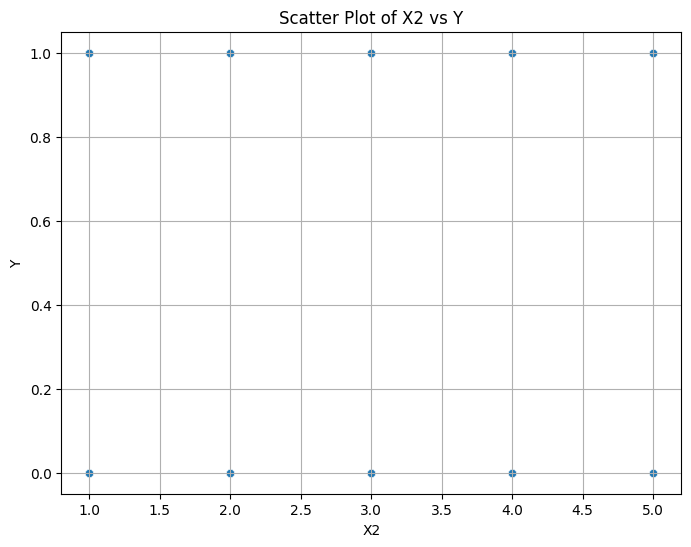

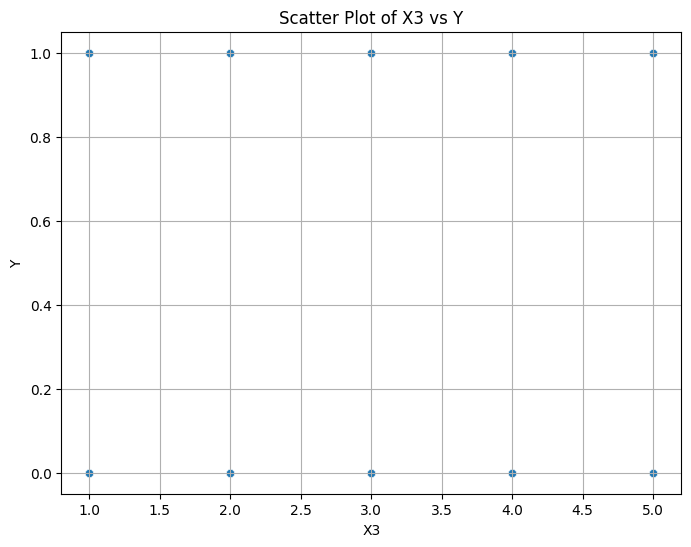

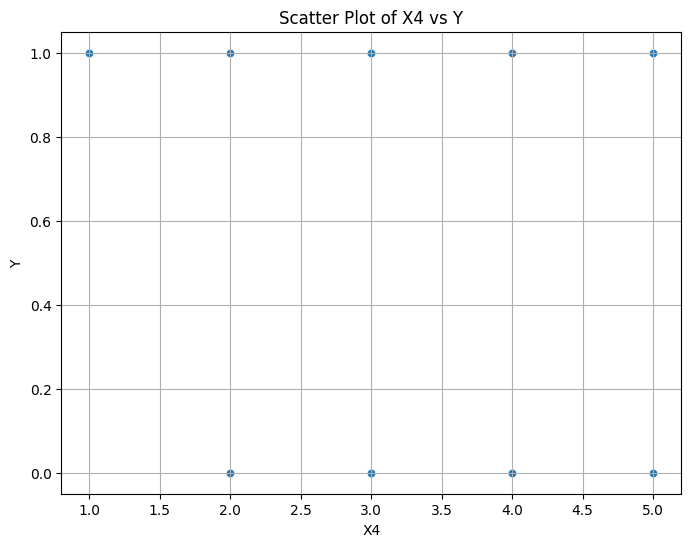

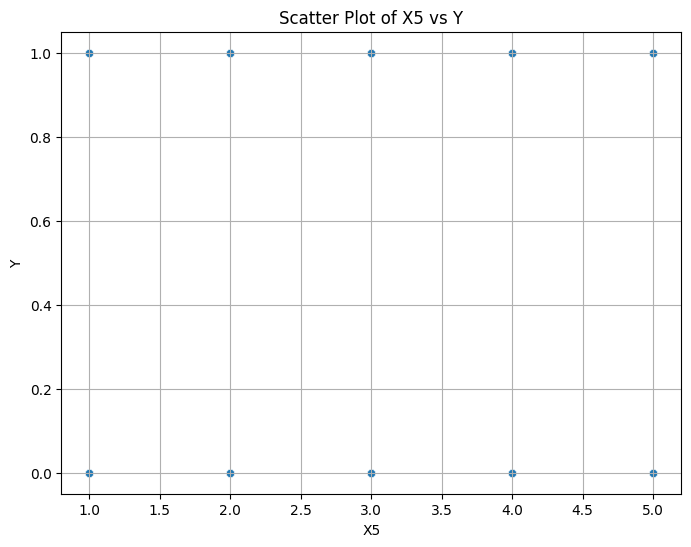

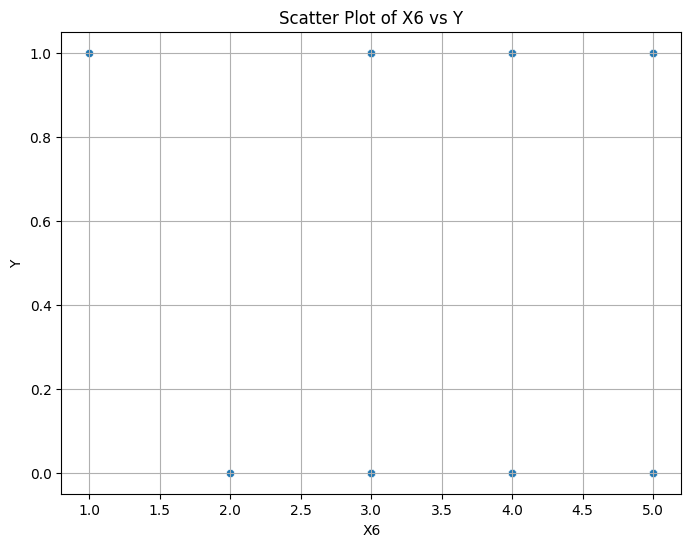

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in attribute_df.columns:
  # Choose the two columns you want to plot
  column1 = col
  column2 = 'Y'

  plt.figure(figsize=(8, 6))
  sns.scatterplot(x=df[column1], y=df[column2])
  plt.title(f'Scatter Plot of {column1} vs {column2}')
  plt.xlabel(column1)
  plt.ylabel(column2)
  plt.grid(True)
  plt.show()

# multivariate analysis

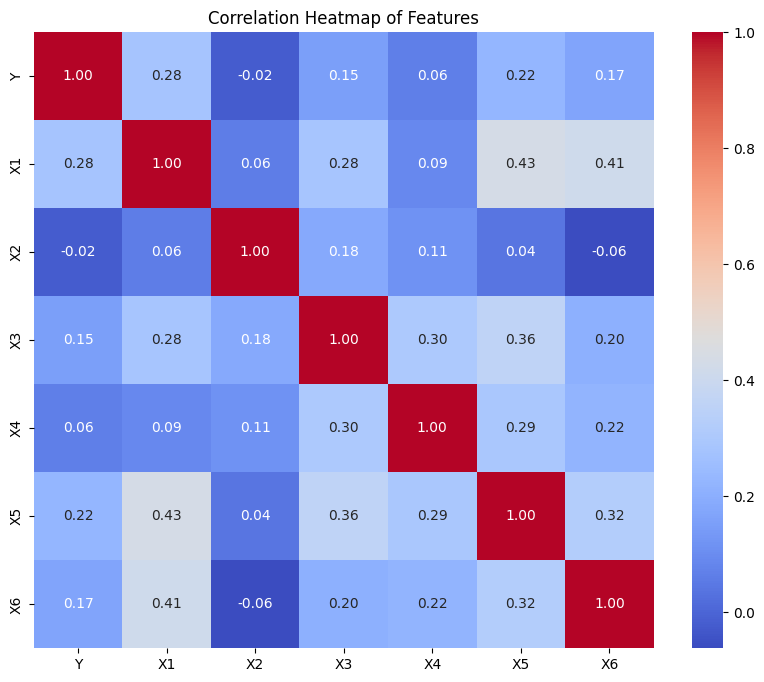

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

# notes

possible ML models

classification

discrete numeric data

*   logistic regression
*   decision tree
*   random forest
*   bayesian model





2025.12.11

Challenges
- limited dataset

Suggestion
- violin plot